# CSCI 3360 Project 

## Instructions

In [95]:
import numpy
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

## Academic Honesty Statement

In [96]:
first_name_one = "Fidel"
last_name_one  = "Arroyo"
first_name_two = "Sanjana"
last_name_two= "Arun"


print("****************************************************************")
print("CSCI 3360 Project")
print(f"completed by {first_name_one} {last_name_one} and  {first_name_two} {last_name_two}")
print(f"""
We, GROUP 11: {first_name_one} {last_name_one} and {first_name_two} {last_name_two}, certify that the following code
represents our own work. We have neither received nor given 
inappropriate assistance. We have not consulted with another
individual, other than a member of the teaching staff, regarding
the specifics of our project. We recognize that any 
unauthorized assistance or plagiarism will be handled in 
accordance with the University of Georgia's Academic Honesty
Policy and the policies of this course.
""")
print("****************************************************************")

****************************************************************
CSCI 3360 Project
completed by Fidel Arroyo and  Sanjana Arun

We, GROUP 11: Fidel Arroyo and Sanjana Arun, certify that the following code
represents our own work. We have neither received nor given 
inappropriate assistance. We have not consulted with another
individual, other than a member of the teaching staff, regarding
the specifics of our project. We recognize that any 
unauthorized assistance or plagiarism will be handled in 
accordance with the University of Georgia's Academic Honesty
Policy and the policies of this course.

****************************************************************


## Loading 

We will first load the data and have the orginal pd as wage_data.

In [97]:
wage_data = pd.read_csv('./median_average_wages.csv')
print(wage_data)

    year  median  average  men_median  men_average  women_median  \
0   2022   22.88    32.00       24.91        35.82         20.74   
1   2021   23.05    32.08       24.93        35.61         21.46   
2   2020   23.64    32.54       25.95        36.03         21.72   
3   2019   22.12    30.36       24.04        33.65         20.42   
4   2018   21.90    29.83       23.42        33.19         19.73   
5   2017   21.55    29.21       23.78        32.27         19.69   
6   2016   21.36    29.00       23.44        32.18         19.44   
7   2015   20.99    28.43       23.19        31.52         19.07   
8   2014   20.65    27.36       22.43        30.08         18.63   
9   2013   20.63    27.54       22.63        30.49         18.87   
10  2012   20.53    27.41       22.87        30.45         19.01   
11  2011   20.79    27.26       22.76        29.99         19.34   
12  2010   21.32    27.84       23.34        30.85         19.47   
13  2009   21.45    27.90       23.90        31.

In [98]:
print(f"Shape: {wage_data.shape}")
print(f"Rows: {wage_data.shape[0]}")
print(f"Columns: {wage_data.shape[1]}")

Shape: (50, 31)
Rows: 50
Columns: 31


In [99]:
group_dfs = []
group_train = []
group_test = []
year_df = wage_data["year"]

split = math.floor(year_df.shape[0] * 0.20)
year_test = year_df[:split]
year_train = year_df[split:]

print(f"Split index is {split}.")
print(f"Train years range from {year_train.min()} to {year_train.max()}.")
print(f"Test years range from {year_test.min()} to {year_test.max()}.")
# print(f"Split year is {year_df[split]}, so we are testing for any year after {year_df[split]}")

Split index is 10.
Train years range from 1973 to 2012.
Test years range from 2013 to 2022.


##  Exploratory Data Analysis

We will showcase our Exploratory Data analysis:  mean, minimum and maximum, and standard deviation for a training set (80%) split. We will also display the histograms for each categorical group.

In [ ]:
i = 0
for group in wage_data.columns:
    if (i > 0):
        temp_df = wage_data[group].dropna()
        test = temp_df[:split]
        train = temp_df[split:]
        trim = train.describe(include=numpy.number).loc[ ['mean', 'std', 'min', 'max', '50%'] ]
        print(f"Train {group}")
        print(trim)
        correlation = train.corr(year_train)
        print(f"Correlation between {group} and year: {correlation}")
        print()
        print()
        group_dfs.append(temp_df)
        group_train.append(train)
        group_test.append(test)
    i+=1

Train median
mean    19.857750
std      0.875075
min     18.780000
max     21.450000
50%     19.385000
Name: median, dtype: float64
Correlation between median and year: 0.7829267929893973


Train average
mean    24.497000
std      1.880201
min     22.420000
max     27.900000
50%     23.700000
Name: average, dtype: float64
Correlation between average and year: 0.9258716327106336


Train men_median
mean    23.083250
std      0.797619
min     21.510000
max     24.270000
50%     23.260000
Name: men_median, dtype: float64
Correlation between men_median and year: -0.296969590750943


Train men_average
mean    27.880750
std      1.599648
min     26.200000
max     31.150000
50%     26.990000
Name: men_average, dtype: float64
Correlation between men_average and year: 0.8324766914479996


Train women_median
mean    17.00050
std      1.56914
min     14.88000
max     19.57000
50%     16.75000
Name: women_median, dtype: float64
Correlation between women_median and year: 0.9764693117738396


Train w

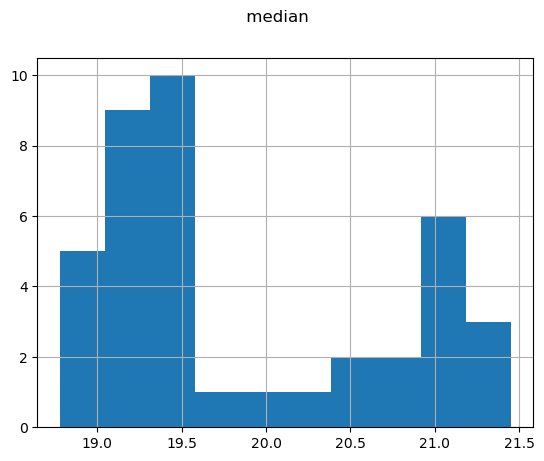

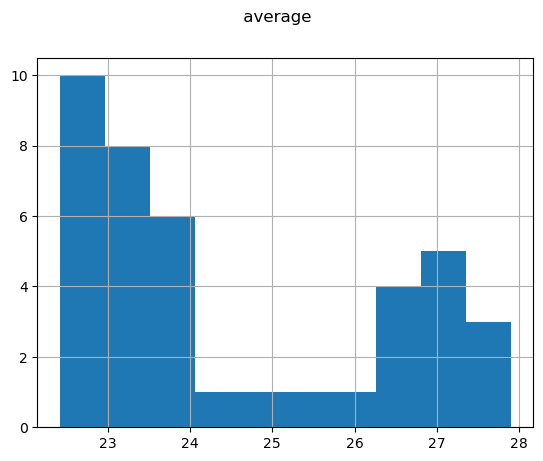

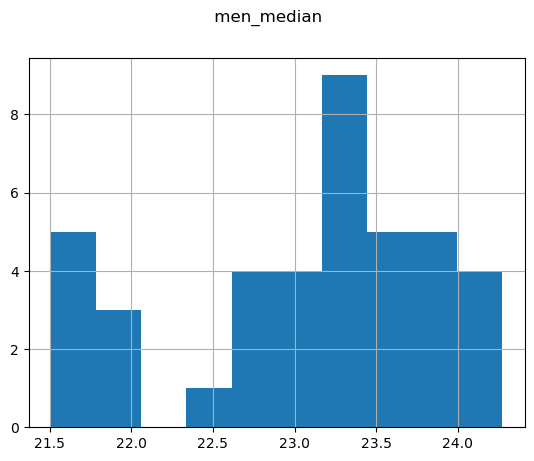

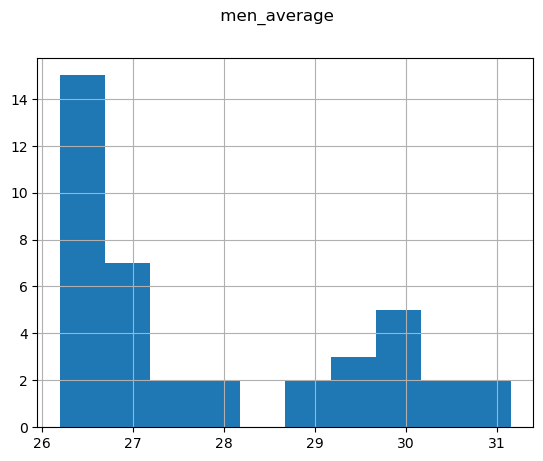

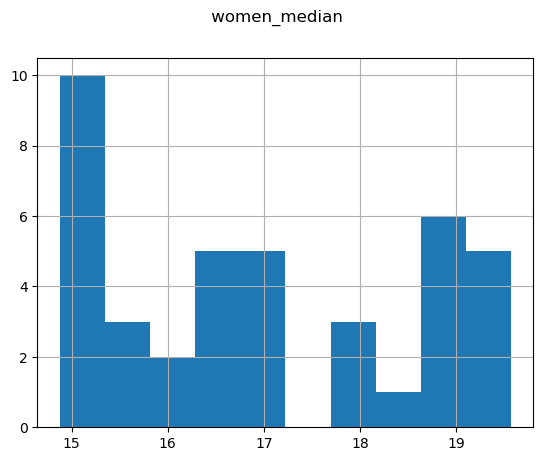

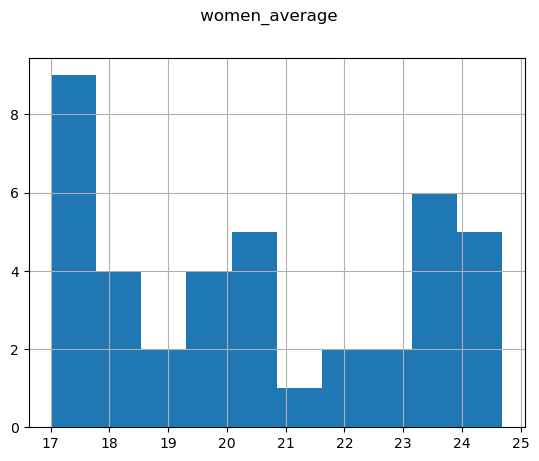

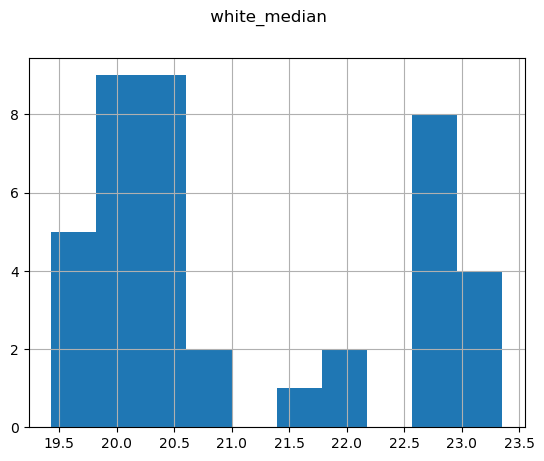

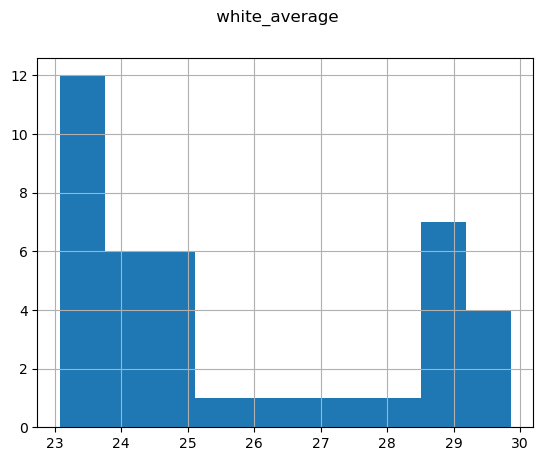

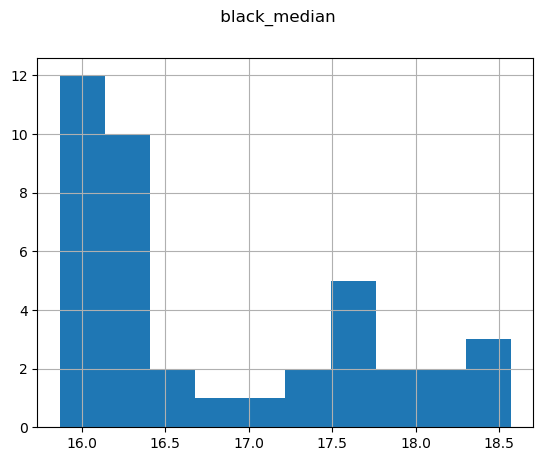

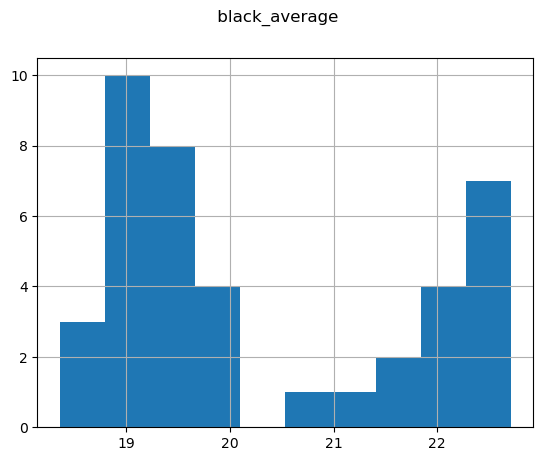

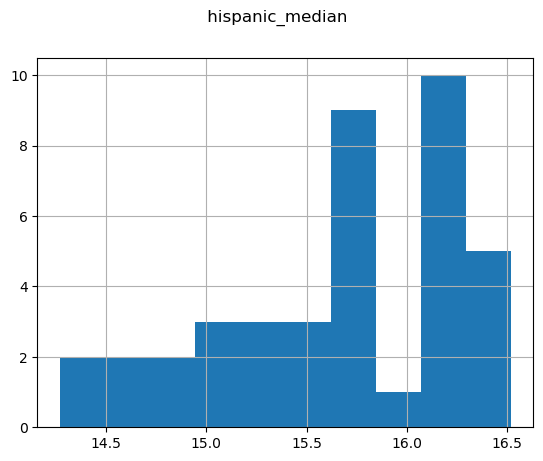

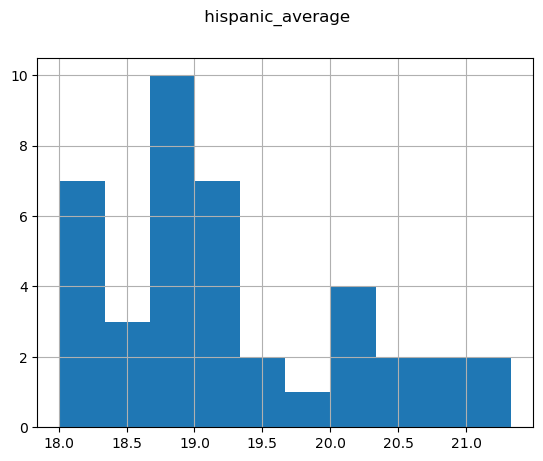

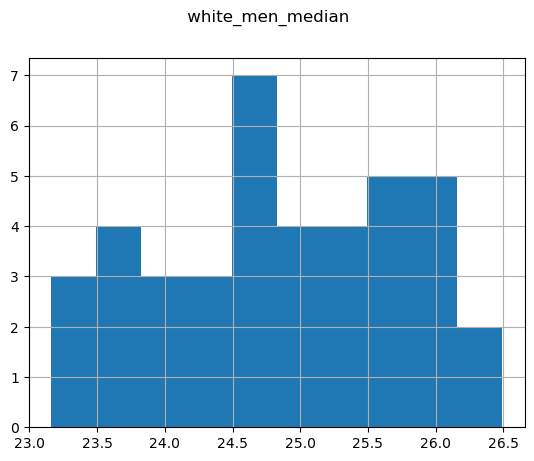

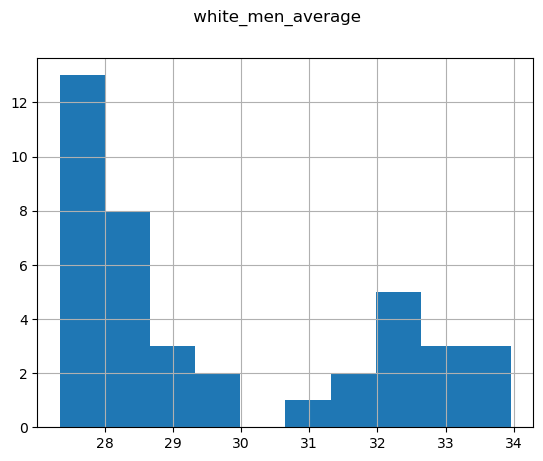

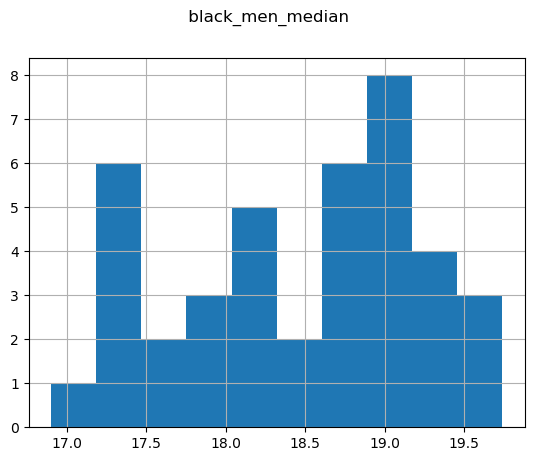

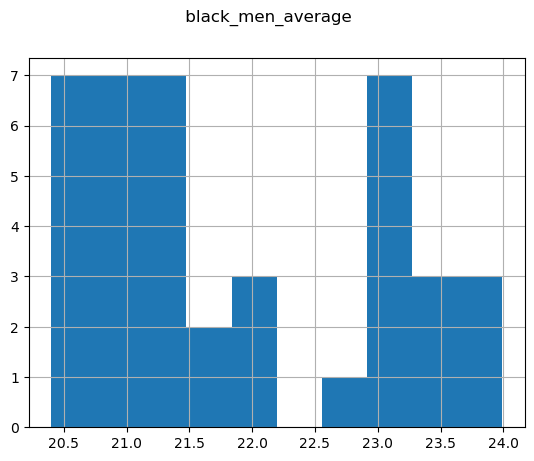

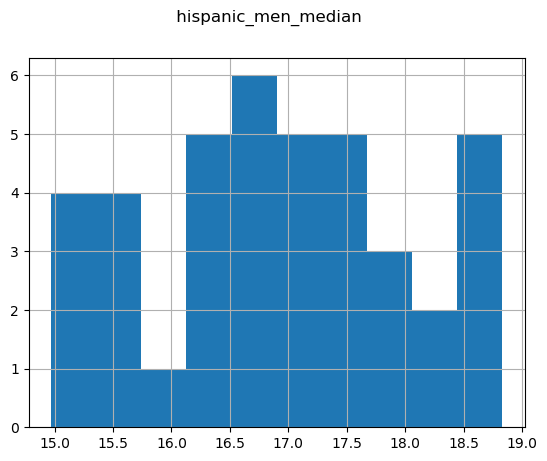

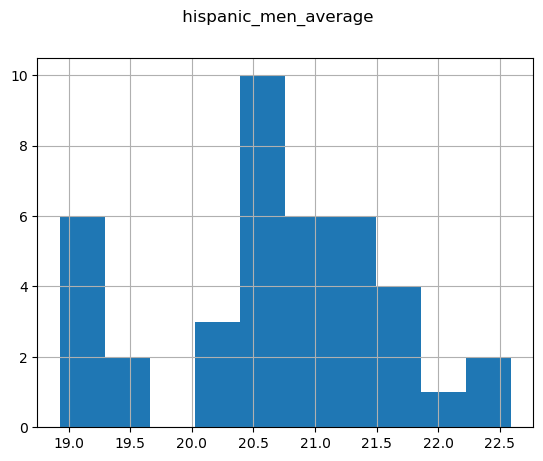

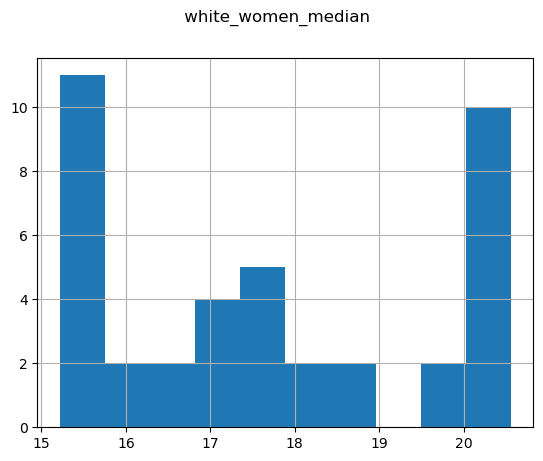

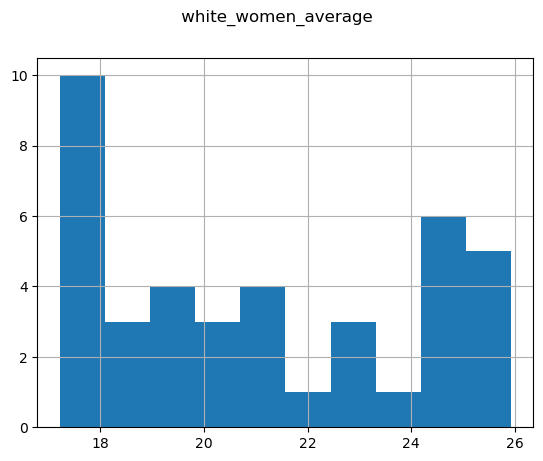

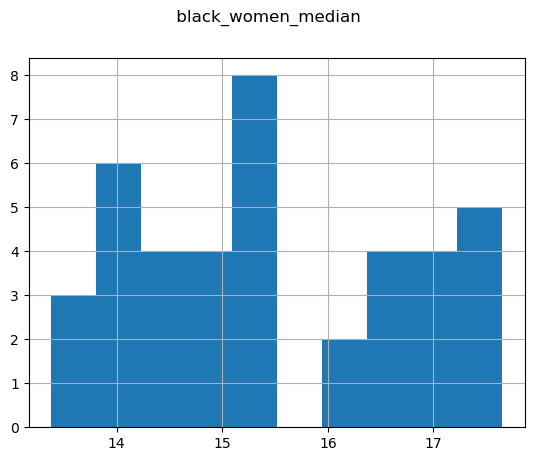

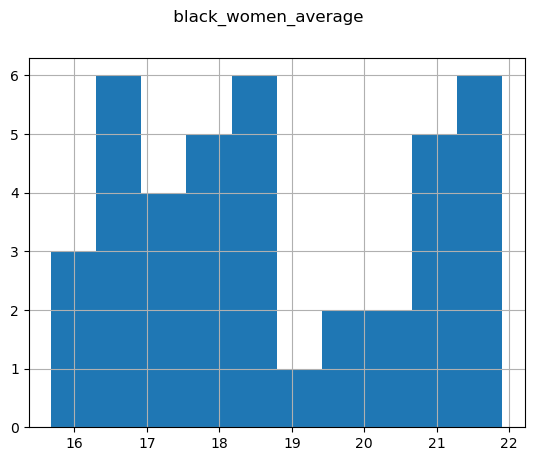

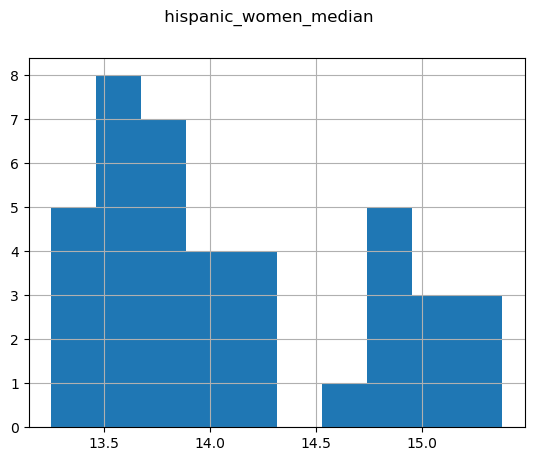

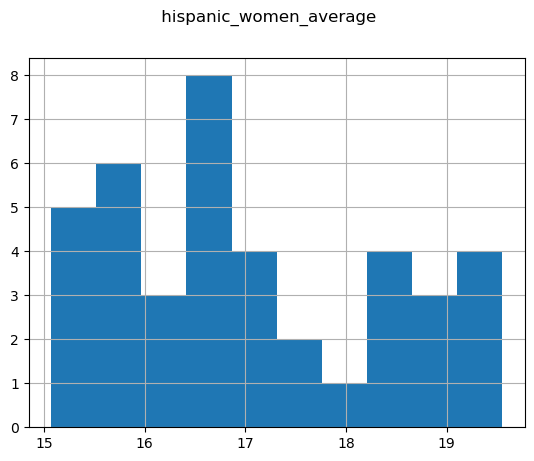

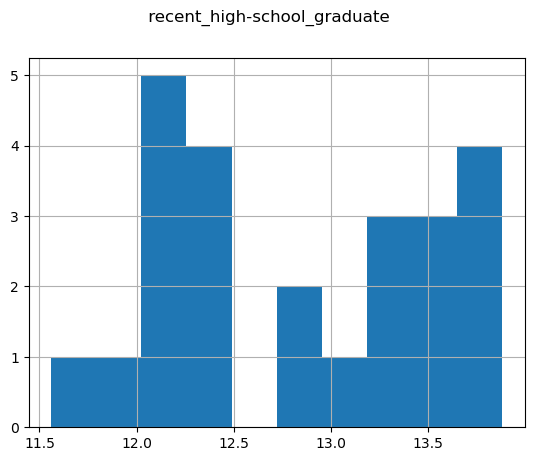

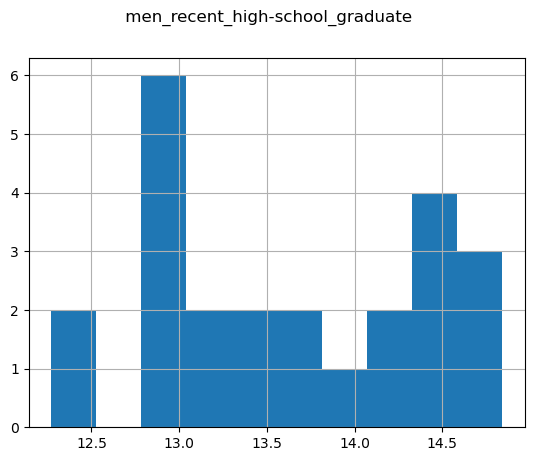

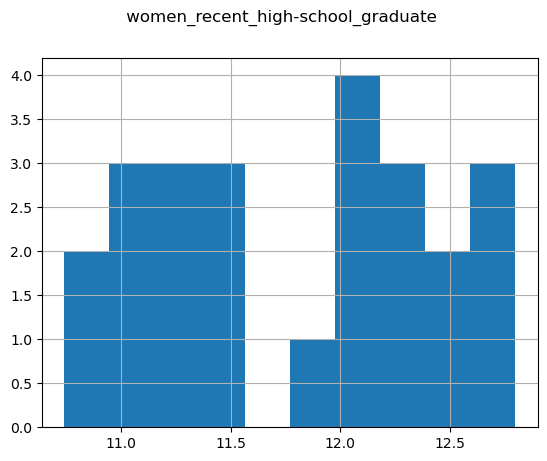

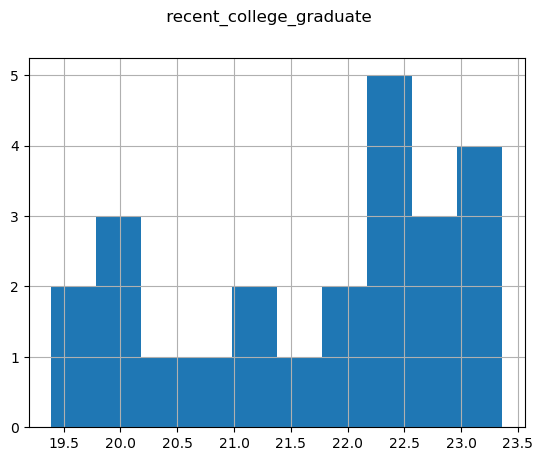

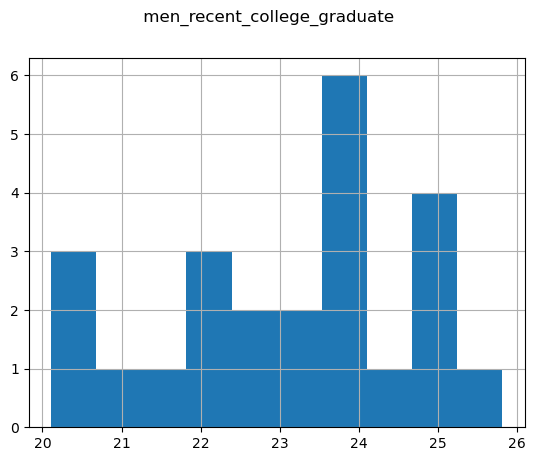

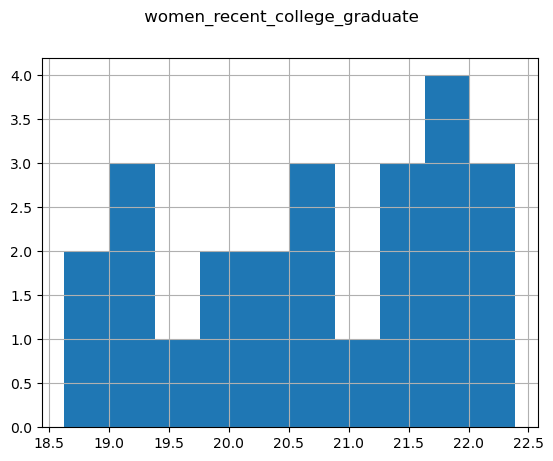

In [ ]:
i = 1
cols = wage_data.columns[i:]
for  df in group_train:
    plt.figure()
    df.hist()
    plt.suptitle(f" {cols[i]} ")
    i += 1
    plt.show()
    plt.close()

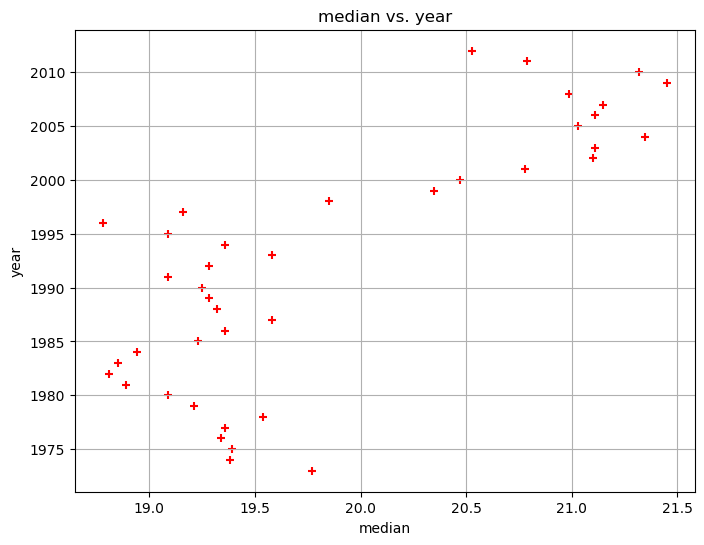

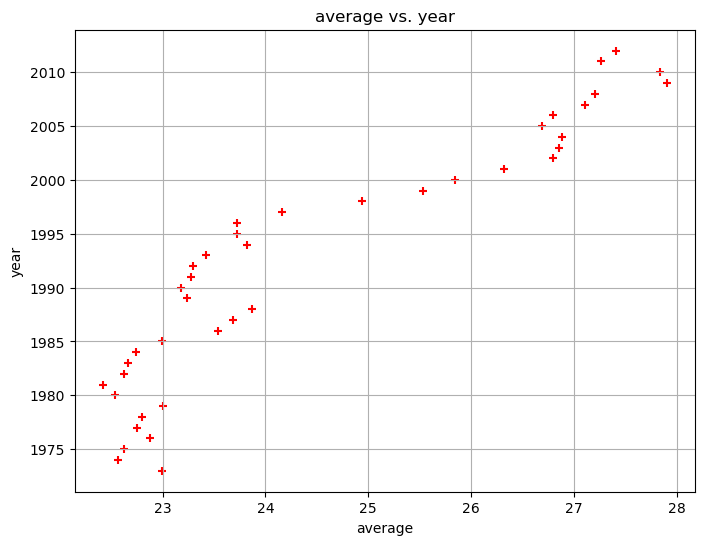

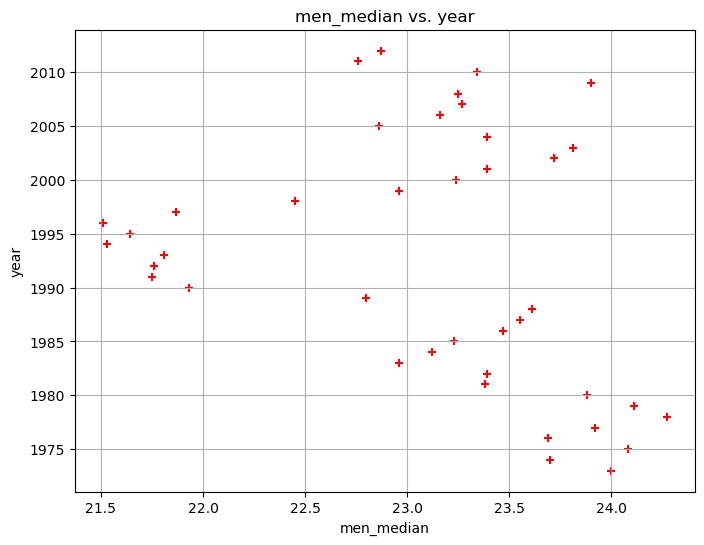

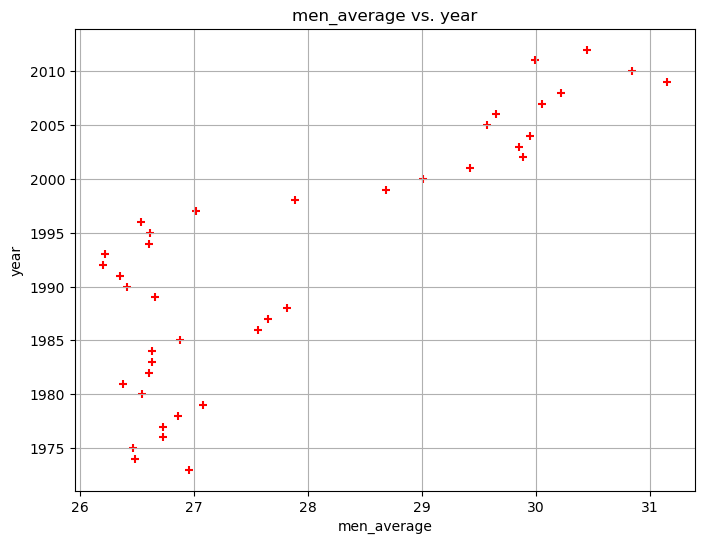

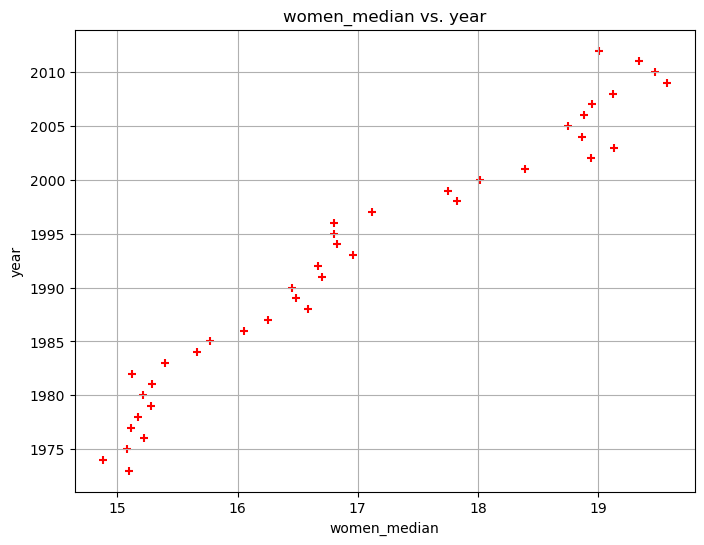

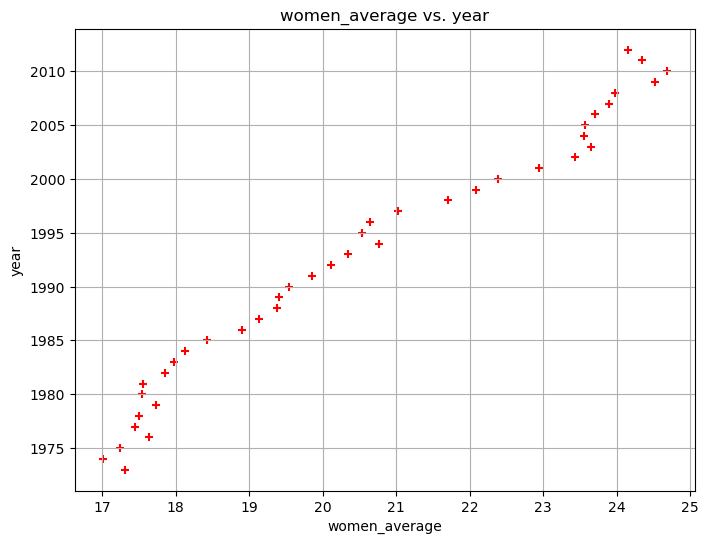

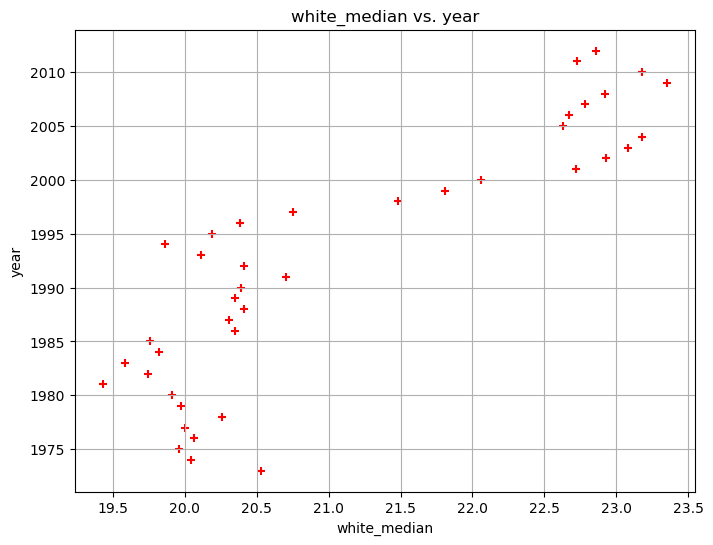

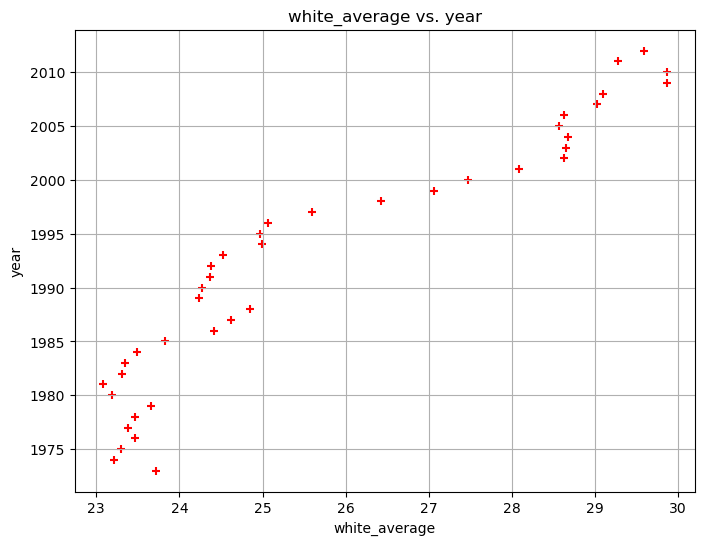

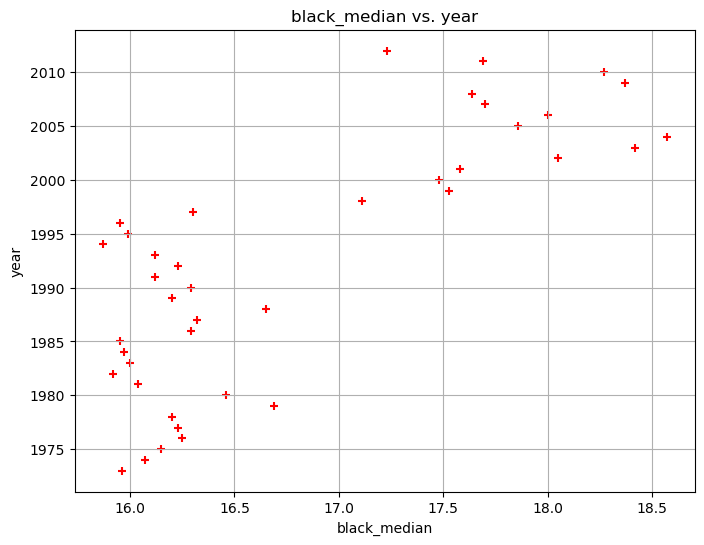

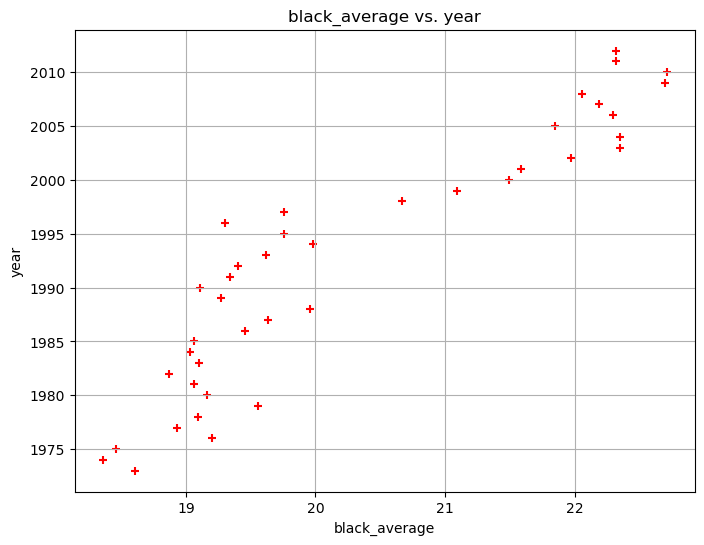

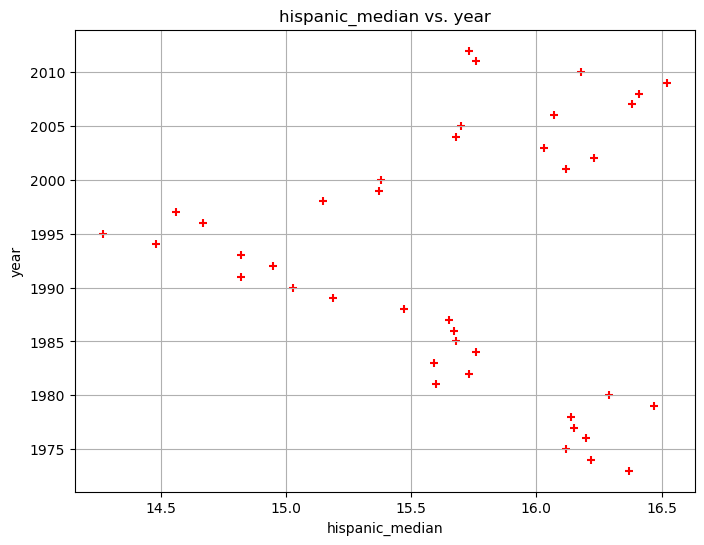

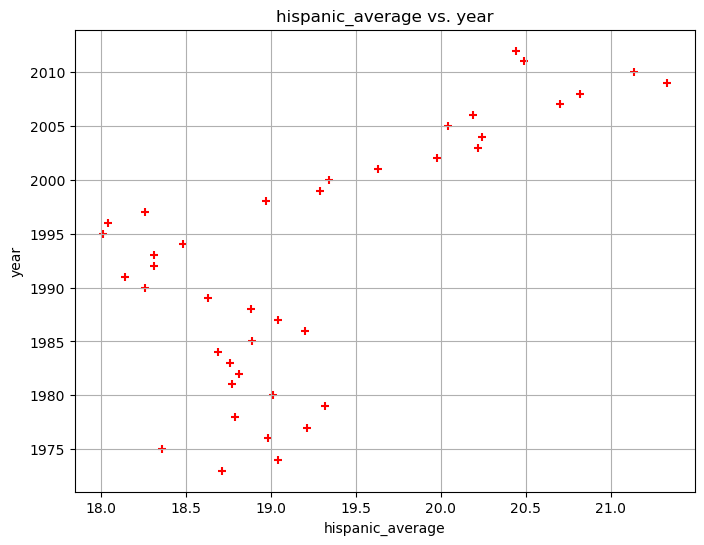

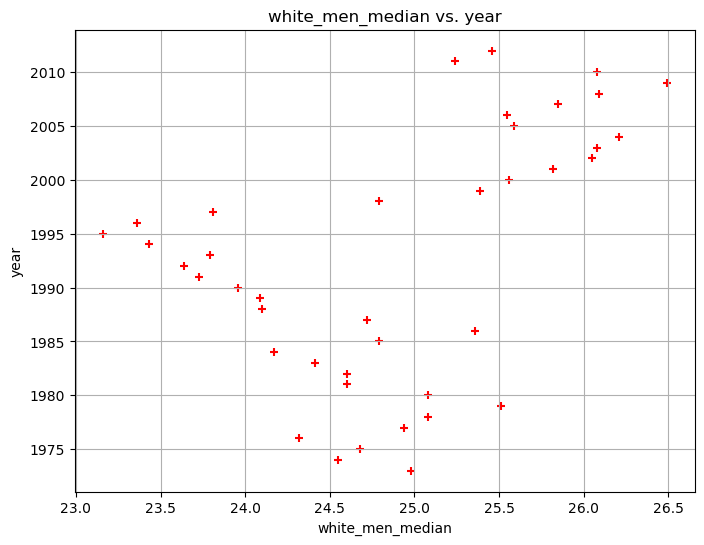

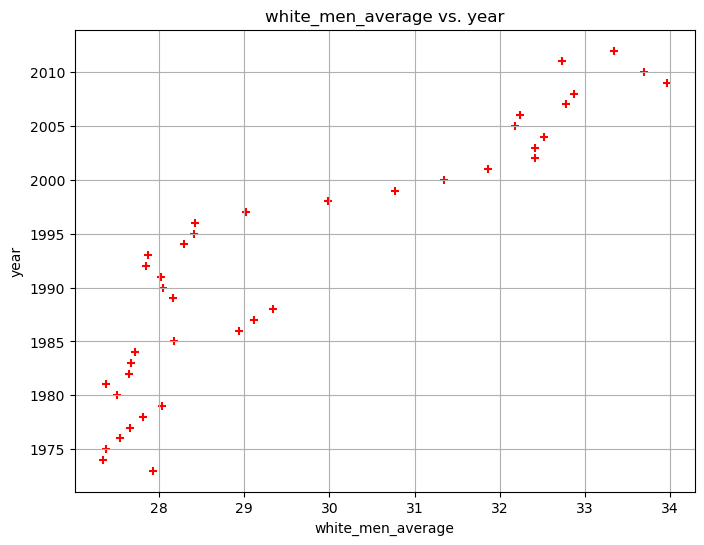

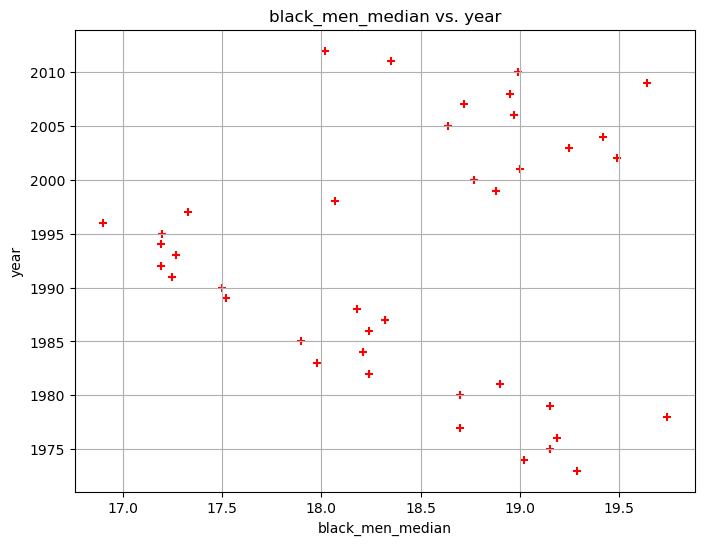

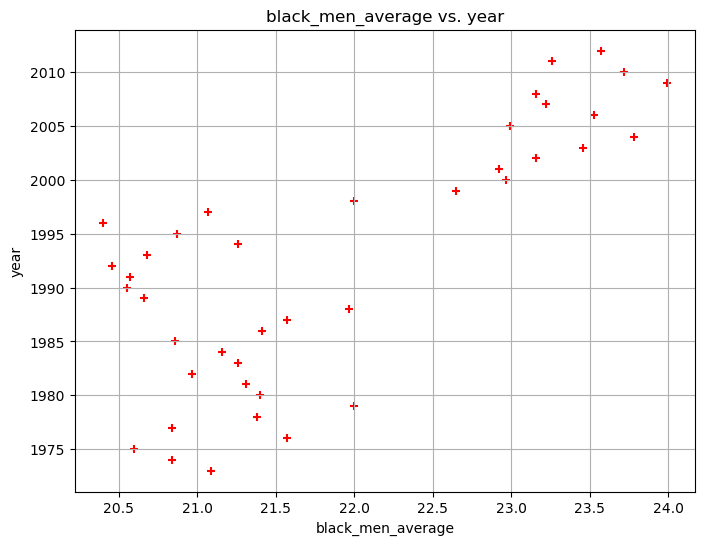

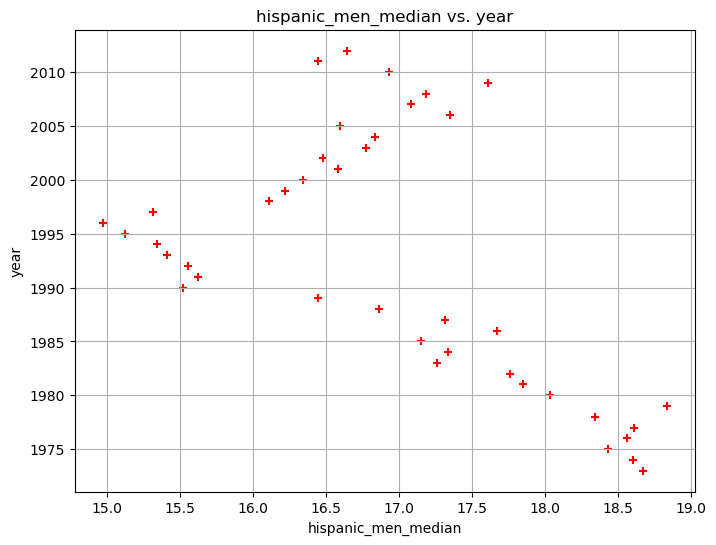

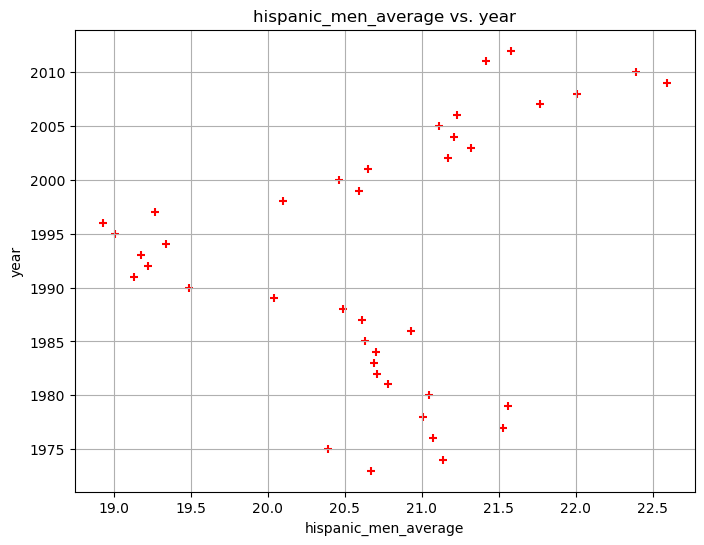

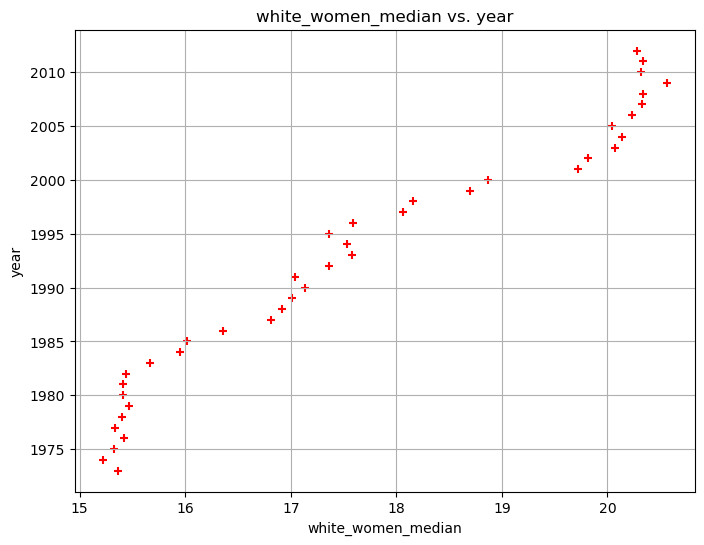

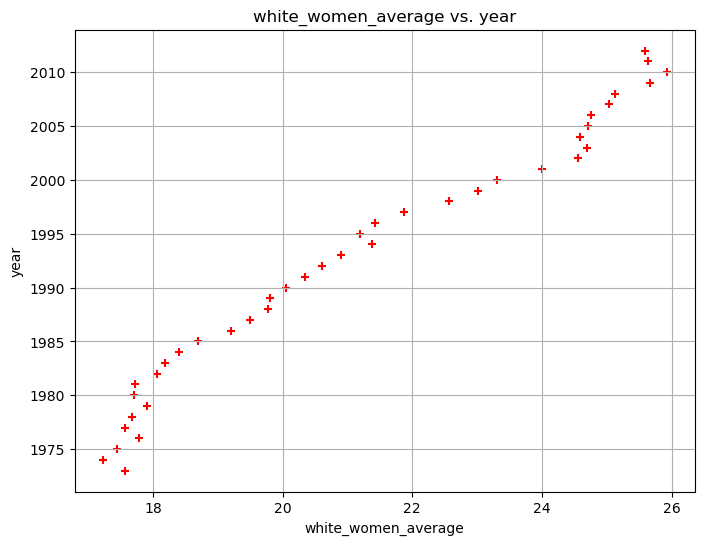

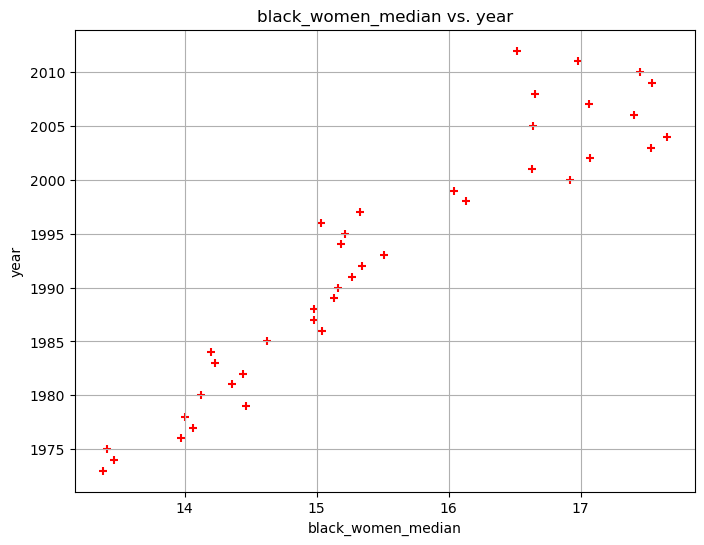

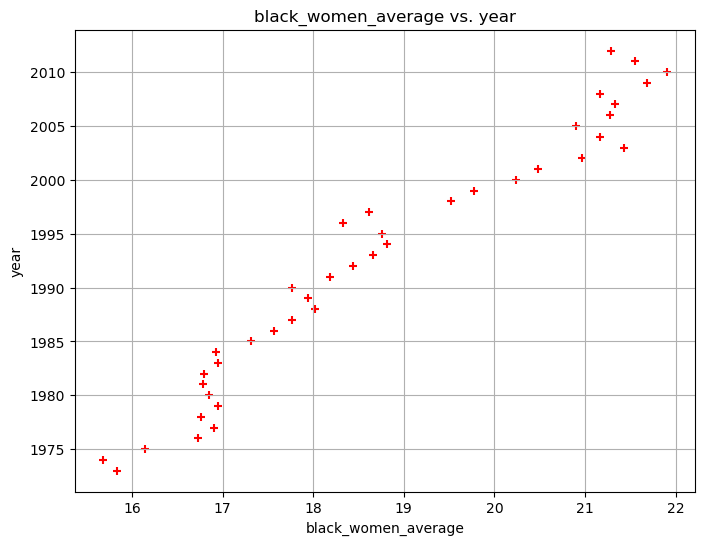

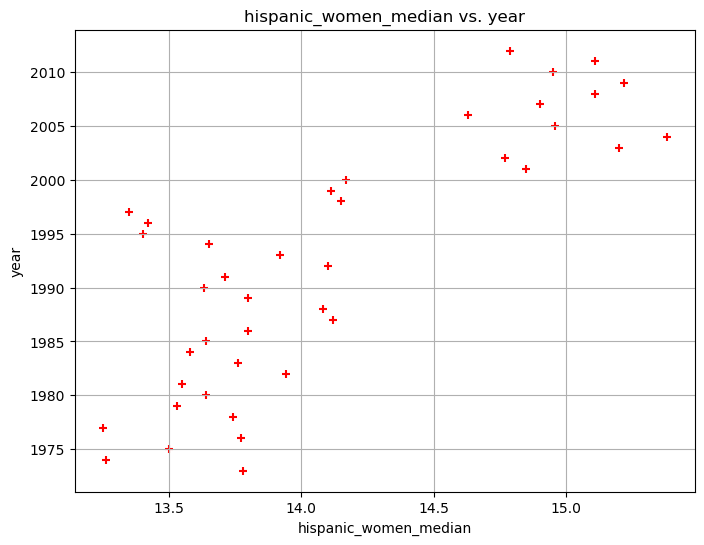

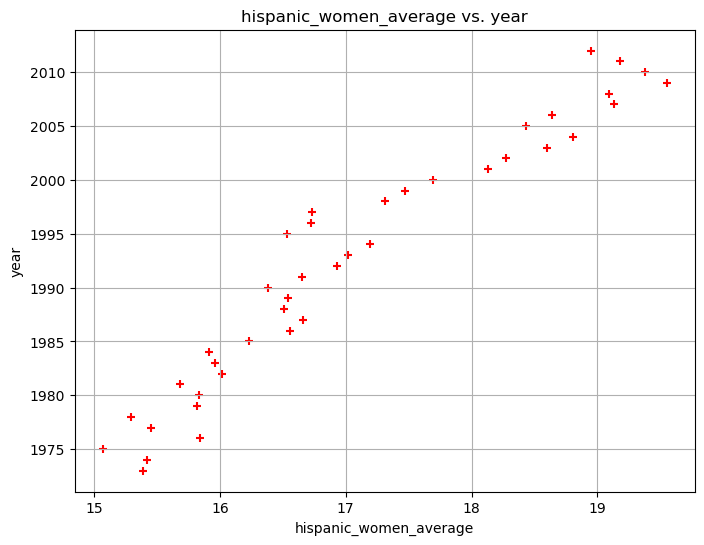

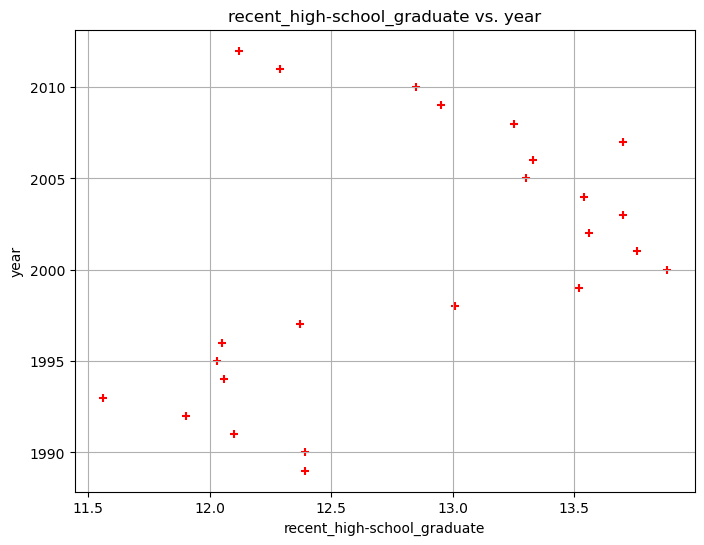

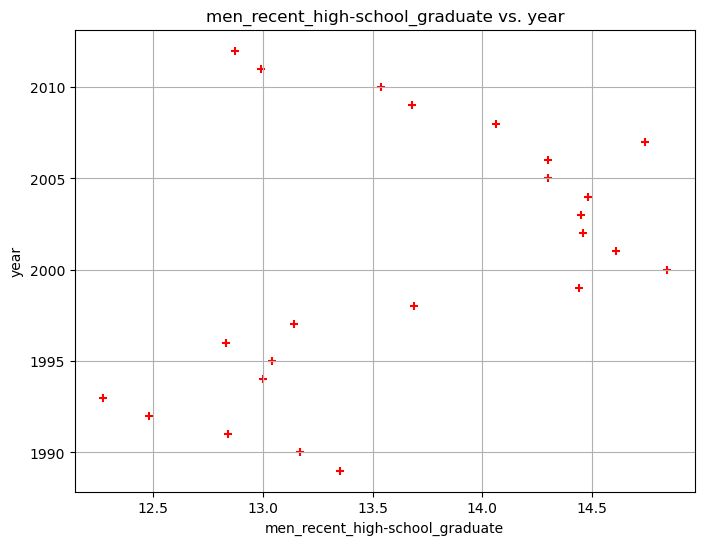

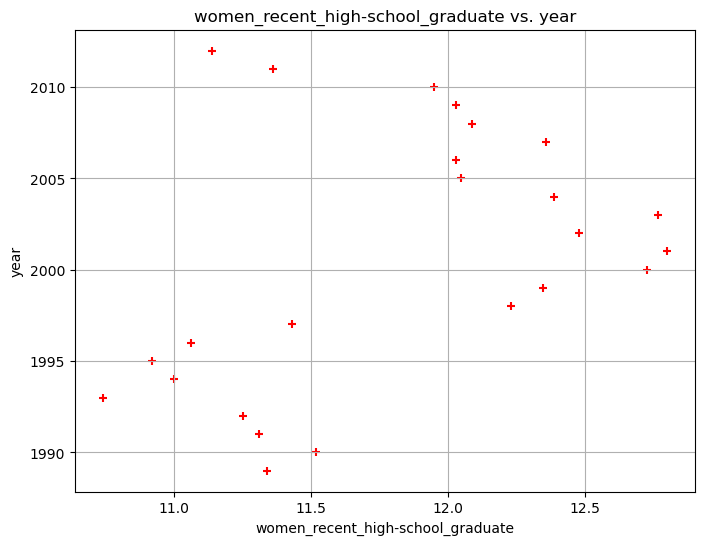

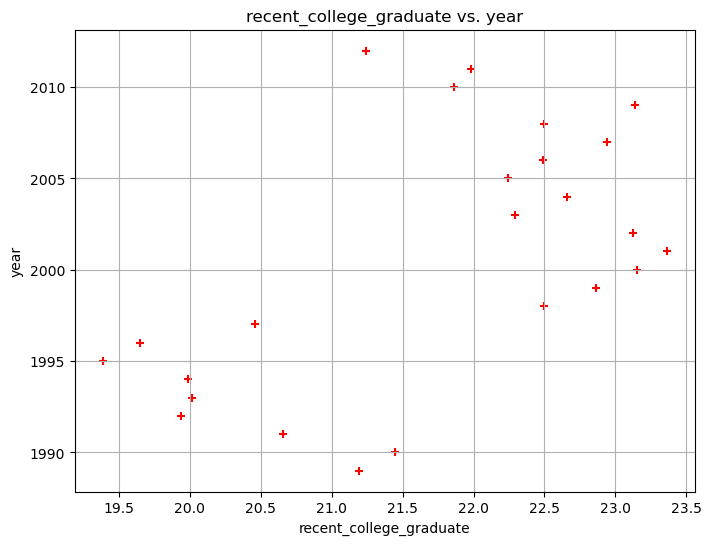

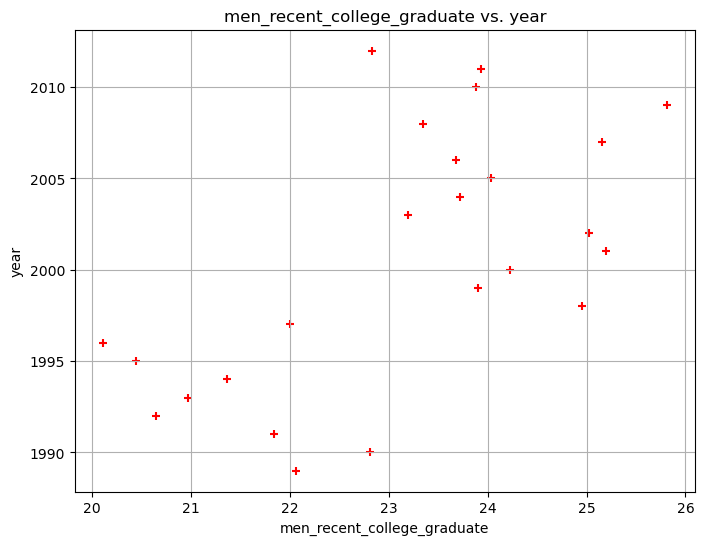

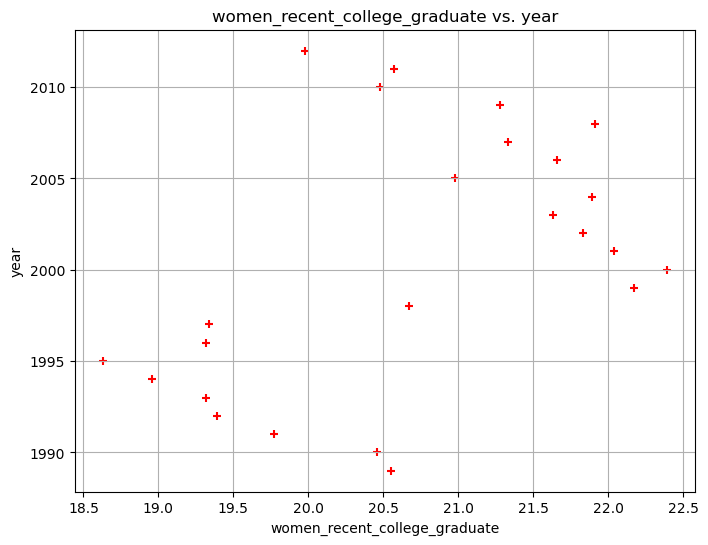

In [102]:
i = 1;
#cols = wage_data.columns[i:]
for df in group_train:
    a = wage_data.columns[i]
    b = wage_data.columns[0]
    plt.figure(figsize=(8,6))
    aligned = pd.concat([df, year_train], axis = 1, keys = [a, b]).dropna()
    plt.scatter(aligned[a], aligned[b], color='red', marker='+')
    plt.title(a + " vs. " + b)
    plt.grid(True)
    plt.xlabel(a)
    plt.ylabel(b)
    plt.show()
    plt.close()
    i+=1

## Visualization

We will visualize the data to see trends within ethinic groups, between genders and so on.


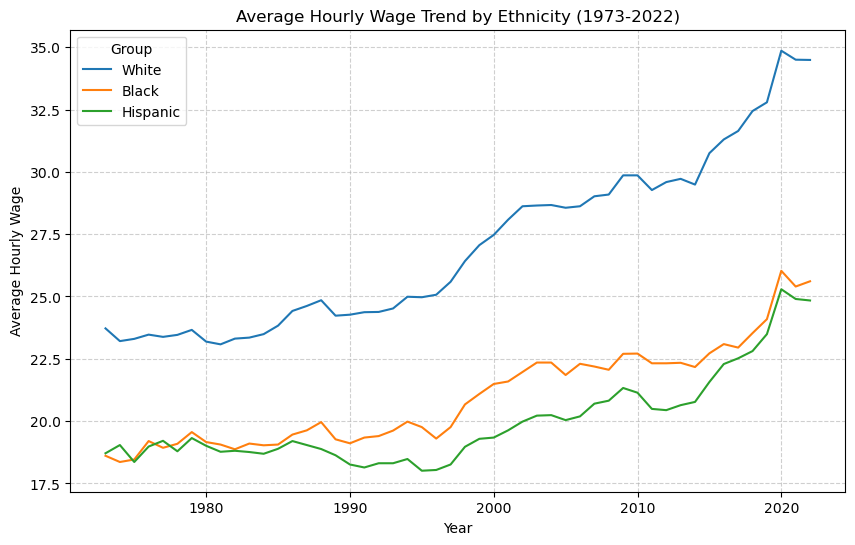

In [103]:
ethnicity_cols = [
    'white_average',
    'black_average',
    'hispanic_average',
]

plot_df = wage_data.dropna(subset=ethnicity_cols + ['year']) # uses the full dataset

plt.figure(figsize=(10, 6))

for column in ethnicity_cols:
    plt.plot(
        plot_df['year'],            # X-axis: Year
        plot_df[column],            # Y-axis: Average Wage for respective group
        label=column.replace('_average', '').title().replace('_', ' ')
    )

plt.title('Average Hourly Wage Trend by Ethnicity (1973-2022)')
plt.xlabel('Year')
plt.ylabel('Average Hourly Wage')
plt.legend(title='Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.close()

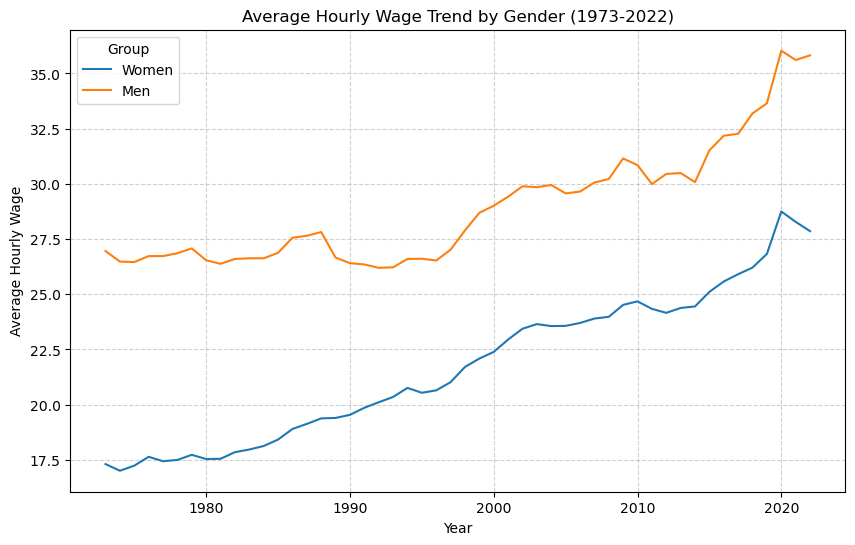

In [104]:
gender_cols = [
    'women_average',
    'men_average',
]

plot_df = wage_data.dropna(subset=gender_cols + ['year']) # uses the full dataset

plt.figure(figsize=(10, 6))

for column in gender_cols:
    plt.plot(
        plot_df['year'],            # X-axis: Year
        plot_df[column],            # Y-axis: Average Wage for respective group
        label=column.replace('_average', '').title().replace('_', ' ')
    )

plt.title('Average Hourly Wage Trend by Gender (1973-2022)')
plt.xlabel('Year')
plt.ylabel('Average Hourly Wage')
plt.legend(title='Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.close()

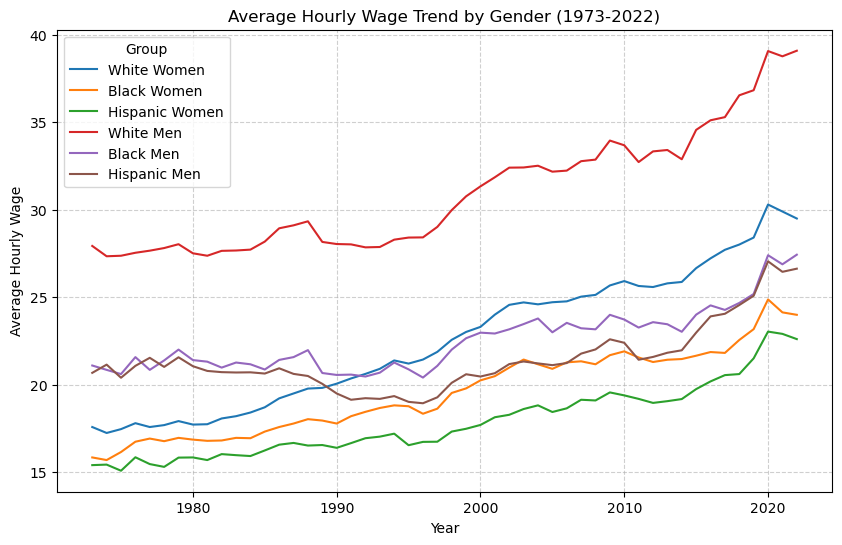

In [105]:
gender_ethnicity_cols = [
    'white_women_average',
    'black_women_average',
    'hispanic_women_average',
    'white_men_average',
    'black_men_average',
    'hispanic_men_average',
]

plot_df = wage_data.dropna(subset=gender_ethnicity_cols + ['year']) # uses the full dataset

plt.figure(figsize=(10, 6))

for column in gender_ethnicity_cols:
    plt.plot(
        plot_df['year'],            # X-axis: Year
        plot_df[column],            # Y-axis: Average Wage for respective group
        label=column.replace('_average', '').title().replace('_', ' ')
    )

plt.title('Average Hourly Wage Trend by Gender (1973-2022)')
plt.xlabel('Year')
plt.ylabel('Average Hourly Wage')
plt.legend(title='Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
plt.close()

# Linear Regression

### Feature Preparation

### Linear Regression Model Training + Testing

### Linear Regression Model Evaluation Metrics